In [330]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import json
import unicodedata
import plotly.graph_objects as go

In [134]:
Data = pd.read_csv('DataAWS.csv')
Data.columns.tolist()

['periodo',
 'estu_tipodocumento',
 'estu_consecutivo',
 'cole_area_ubicacion',
 'cole_bilingue',
 'cole_calendario',
 'cole_caracter',
 'cole_cod_dane_establecimiento',
 'cole_cod_dane_sede',
 'cole_cod_depto_ubicacion',
 'cole_cod_mcpio_ubicacion',
 'cole_codigo_icfes',
 'cole_depto_ubicacion',
 'cole_genero',
 'cole_jornada',
 'cole_mcpio_ubicacion',
 'cole_naturaleza',
 'cole_nombre_establecimiento',
 'cole_nombre_sede',
 'cole_sede_principal',
 'estu_cod_depto_presentacion',
 'estu_cod_mcpio_presentacion',
 'estu_cod_reside_depto',
 'estu_cod_reside_mcpio',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_estudiante',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_cuartoshogar',
 'fami_educacionmadre',
 'fami_educacionpadre',
 'fami_estratovivienda',
 'fami_personashogar',
 'fami_tieneautomovil',
 'fami_tienecomputador',
 'fam

In [ ]:
cols_used = ['fami_educacionmadre', 'fami_educacionpadre', #heatmap
             'cole_area_ubicacion', 'cole_caracter','cole_naturaleza','cole_jornada', #barplots apilados y donas y geograficos
             'cole_mcpio_ubicacion',
             
             'punt_matematicas','punt_c_naturales'] # histograma kde
Data_used = Data[cols_used]

In [ ]:
mapeo_educativo = {'Educación profesional completa': 4,
 'Educación profesional incompleta': 3.5,
 'Ninguno': 0,
 'No Aplica': 0,
 'No sabe': 0,
 'Postgrado': 5,
 'Primaria completa': 1,
 'Primaria incompleta': 0.5,
 'Secundaria (Bachillerato) completa': 2,
 'Secundaria (Bachillerato) incompleta': 1.5,
 'Técnica o tecnológica completa': 3,
 'Técnica o tecnológica incompleta': 2.5
 }
# proemdio padre - madre mapeado

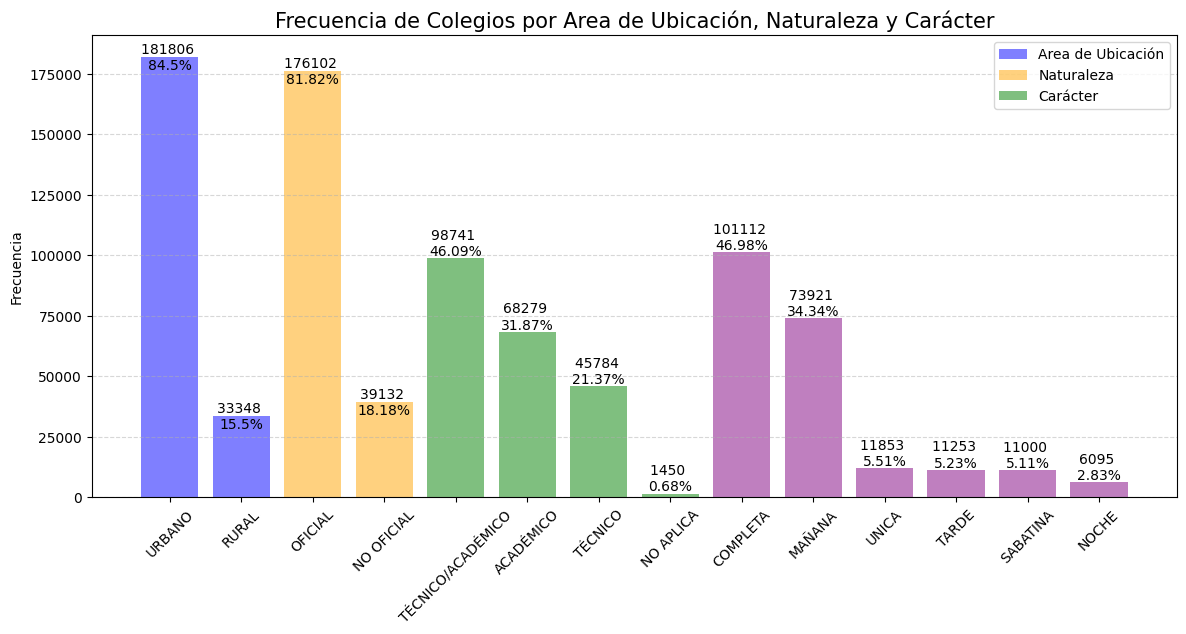

In [ ]:
plt.figure(figsize=(14,6))
plt.bar(Data_used['cole_area_ubicacion'].value_counts().index, Data_used['cole_area_ubicacion'].value_counts().values, color='blue', alpha=0.5)
plt.bar(Data_used['cole_naturaleza'].value_counts().index, Data_used['cole_naturaleza'].value_counts().values, color='orange', alpha=0.5)
plt.bar(Data_used['cole_caracter'].dropna().value_counts().index, Data_used['cole_caracter'].dropna().value_counts().values, color='green', alpha=0.5)
plt.bar(Data_used['cole_jornada'].dropna().value_counts().index, Data_used['cole_jornada'].dropna().value_counts().values, color='purple', alpha=0.5)

# GEOGRAFICOS
for i in range(len(Data_used['cole_area_ubicacion'].value_counts().index)):
    plt.text(i, Data_used['cole_area_ubicacion'].value_counts().values[i], 
             f"{Data_used['cole_area_ubicacion'].value_counts().values[i]} \n{round(Data_used['cole_area_ubicacion'].value_counts().values[i]/Data_used['cole_area_ubicacion'].value_counts().values.sum() * 100, 2)}%", 
             ha='center', va='center')
    
for i in range(len(Data_used['cole_naturaleza'].value_counts().index)):
    plt.text(i+2, Data_used['cole_naturaleza'].value_counts().values[i], 
             f"{Data_used['cole_naturaleza'].value_counts().values[i]} \n{round(Data_used['cole_naturaleza'].value_counts().values[i]/Data_used['cole_naturaleza'].value_counts().values.sum() * 100, 2)}%", 
             ha='center', va='center')

# DONAS
for i in range(len(Data_used['cole_caracter'].dropna().value_counts().index)): 
    plt.text(i+4, Data_used['cole_caracter'].dropna().value_counts().values[i], 
             f"{Data_used['cole_caracter'].dropna().value_counts().values[i]} \n{round(Data_used['cole_caracter'].dropna().value_counts().values[i]/Data_used['cole_caracter'].dropna().value_counts().values.sum() * 100, 2)}%", 
             ha='center', va='bottom')
    
for i in range(len(Data_used['cole_jornada'].dropna().value_counts().index)):
    plt.text(i+8, Data_used['cole_jornada'].dropna().value_counts().values[i], 
             f"{Data_used['cole_jornada'].dropna().value_counts().values[i]} \n{round(Data_used['cole_jornada'].dropna().value_counts().values[i]/Data_used['cole_jornada'].dropna().value_counts().values.sum() * 100, 2)}%", 
             ha='center', va='bottom')    
    
    
plt.ylabel('Frecuencia')
plt.title('Frecuencia de Colegios por Area de Ubicación, Naturaleza y Carácter', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Area de Ubicación', 'Naturaleza', 'Carácter'])
plt.show()

### MAPA

In [ ]:
with open('gadm41_COL_2.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)
    
with open('gadm41_COL_1.json', 'r', encoding='utf-8') as f:
    geojson_dpto = json.load(f)
    
boyaca_dpto = next(f for f in geojson_dpto['features'] 
                   if normalizar(f['properties']['NAME_1']) == 'boyaca')
            
def normalizar(name):
    name = name.lower().strip()
    name = unicodedata.normalize('NFKD', name)
    name = ''.join(c for c in name if not unicodedata.combining(c))
    name = name.replace(' ', '')
    name = name.replace('cienega', 'cienaga')
    name = name.replace('guicandelasierra', 'guican')  
    name = name.replace('pisva', 'pisba')              
    name = name.replace('tutasa', 'tutaza')            
    return name

data_municipios = set(Data['cole_mcpio_ubicacion'].dropna().unique())
data_municipios_normal = {normalizar(m): m for m in data_municipios}

geos_coinc = []
for feature in geojson_data['features'][212:335]:
    nombre_municipio = feature['properties']['NAME_2']
    if normalizar(nombre_municipio) in data_municipios_normal:
        geos_coinc.append(feature)

filtered_geojson = {
    "type": "FeatureCollection",
    "features": geos_coinc
}
for i, feature in enumerate(filtered_geojson['features']):
    feature['id'] = i

plot_df = pd.DataFrame([
    {"id": i, "name": f['properties']['NAME_2']}
    for i, f in enumerate(filtered_geojson['features'])
])    

center_coords = geos_coinc[0]['geometry']['coordinates'][0][0][0]


In [329]:
border_lats, border_lons = [], []
geom = boyaca_dpto['geometry']
polys = geom['coordinates'] if geom['type'] == 'Polygon' else geom['coordinates']
for poly in polys:
    ring = poly[0]
    border_lons.extend([p[0] for p in ring] + [None])
    border_lats.extend([p[1] for p in ring] + [None])
        
fig = go.Figure(go.Choroplethmap(
    geojson=filtered_geojson,
    locations=plot_df['id'],
    z=[1] * len(plot_df),  # uniform color, replace with a real column if needed
    colorscale="Blues",
    marker_opacity=0.5,
    marker_line_width=1,
    text=plot_df['name'],
    hovertemplate="<b>%{text}</b><extra></extra>",
    showscale=False
))

fig.add_trace(go.Scattermap(
    lat=border_lats,
    lon=border_lons,
    mode='lines',
    line=dict(width=2.5, color='darkblue'),
    hoverinfo='skip',
    showlegend=False
))

fig.update_layout(
    map_style="carto-positron",
    map_zoom=7,
    map_center={
        "lat": center_coords[1],
        "lon": center_coords[0]
    },
    margin={"r":0,"t":0,"l":0,"b":0}
)

fig.write_html("boyaca_map.html")